---
##  Deep Dive: Which Sequences End Up in Rogue Packs?

# Investigation: Sawtooth Loss Pattern and Token Drops

## Hypothesis
The token drops and sawtooth loss pattern are caused by **dataset restarts mid-training** when `num_train_epochs=1` completes before `max_steps` is reached.

### Key Issue
HuggingFace Trainer stops training when **either** condition is met first:
1. `num_train_epochs` completes (dataset exhausted)
2. `max_steps` is reached

If max_steps > steps_per_epoch, the dataset **restarts from the beginning**, causing:
- End-of-epoch flush effects (small batches with poor packing)
- Repeated data (lower loss after restart)
- Token count drops at epoch boundaries

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 1. Load Dataset Metadata

In [2]:
# Load metadata
metadata_path = Path('../data/mixed_milestone_dataset/metadata.json')
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print("Dataset Metadata:")
print(f"  Total examples: {metadata['total_examples']:,}")
print(f"  Total tokens: {metadata['total_tokens']:,}")
print(f"  Num milestones: {metadata['num_milestones']}")
print(f"  Tokens per milestone: {metadata['tokens_per_milestone']:,}")
print(f"  Milestone boundaries (example indices): {metadata['milestone_boundaries']}")

# Calculate examples per milestone
boundaries = [0] + metadata['milestone_boundaries']
examples_per_milestone = [boundaries[i+1] - boundaries[i] for i in range(len(boundaries)-1)]
print(f"\nExamples per milestone: {examples_per_milestone}")

Dataset Metadata:
  Total examples: 219,505
  Total tokens: 267,585,027
  Num milestones: 5
  Tokens per milestone: 5,000,000
  Milestone boundaries (example indices): [4084, 8279, 12395, 16481, 20671]

Examples per milestone: [4084, 4195, 4116, 4086, 4190]


## 2. Calculate Training Configuration

From train_milestone_segment.log analysis:
- batch_size = 32
- gradient_accumulation_steps = 1
- seq_length = 2048
- num_train_epochs = 1
- validation_split = 0.1 (10% for validation)

In [3]:
# Training configuration
batch_size = 32
grad_accum = 1
seq_length = 2048
world_size = 1
num_train_epochs = 1
validation_split = 0.1

# Calculate tokens per step
tokens_per_step = batch_size * grad_accum * seq_length * world_size
print(f"Tokens per step: {tokens_per_step:,}")

# Calculate effective batch size
effective_batch_size = batch_size * grad_accum
print(f"Effective batch size: {effective_batch_size}")

Tokens per step: 65,536
Effective batch size: 32


## 3. Calculate Max Steps vs Steps Per Epoch for Each Milestone

In [4]:
# Tokens per milestone from metadata
target_tokens_per_milestone = metadata['tokens_per_milestone']

# Calculate max_steps for each milestone (what the training script calculates)
def calculate_max_steps(target_tokens, batch_size, grad_accum, seq_length, world_size):
    tokens_per_step = batch_size * grad_accum * seq_length * world_size
    return target_tokens // tokens_per_step

print("="*80)
print("MILESTONE ANALYSIS: Max Steps vs Epoch Capacity")
print("="*80)

for i, num_examples in enumerate(examples_per_milestone):
    # Account for validation split (90% train, 10% val)
    train_examples = int(num_examples * (1 - validation_split))
    val_examples = num_examples - train_examples
    
    # Calculate steps per epoch (how many steps to go through the dataset once)
    steps_per_epoch = train_examples / effective_batch_size
    
    # Calculate max_steps (target steps based on token target)
    max_steps = calculate_max_steps(
        target_tokens=target_tokens_per_milestone,
        batch_size=batch_size,
        grad_accum=grad_accum,
        seq_length=seq_length,
        world_size=world_size
    )
    
    # Calculate how many epochs would be needed to reach max_steps
    epochs_required = max_steps / steps_per_epoch if steps_per_epoch > 0 else 0
    
    # Check if dataset will restart
    will_restart = max_steps > steps_per_epoch
    num_restarts = int(epochs_required) if will_restart else 0
    
    print(f"\nMilestone {i}:")
    print(f"  Total examples: {num_examples:,}")
    print(f"  Train examples: {train_examples:,} (90%)")
    print(f"  Val examples: {val_examples:,} (10%)")
    print(f"  Steps per epoch: {steps_per_epoch:.1f}")
    print(f"  Max steps (target): {max_steps}")
    print(f"  Epochs required: {epochs_required:.2f}")
    print(f"  Dataset will restart: {'YES ❌' if will_restart else 'NO ✓'}")
    if will_restart:
        print(f"  Number of restarts: {num_restarts}")
        print(f"  ⚠️  WARNING: Training will see repeated data!")
        # Calculate at which steps restarts occur
        restart_steps = [int(steps_per_epoch * (j+1)) for j in range(num_restarts)]
        print(f"  Restart occurs at steps: {restart_steps}")

MILESTONE ANALYSIS: Max Steps vs Epoch Capacity

Milestone 0:
  Total examples: 4,084
  Train examples: 3,675 (90%)
  Val examples: 409 (10%)
  Steps per epoch: 114.8
  Max steps (target): 76
  Epochs required: 0.66
  Dataset will restart: NO ✓

Milestone 1:
  Total examples: 4,195
  Train examples: 3,775 (90%)
  Val examples: 420 (10%)
  Steps per epoch: 118.0
  Max steps (target): 76
  Epochs required: 0.64
  Dataset will restart: NO ✓

Milestone 2:
  Total examples: 4,116
  Train examples: 3,704 (90%)
  Val examples: 412 (10%)
  Steps per epoch: 115.8
  Max steps (target): 76
  Epochs required: 0.66
  Dataset will restart: NO ✓

Milestone 3:
  Total examples: 4,086
  Train examples: 3,677 (90%)
  Val examples: 409 (10%)
  Steps per epoch: 114.9
  Max steps (target): 76
  Epochs required: 0.66
  Dataset will restart: NO ✓

Milestone 4:
  Total examples: 4,190
  Train examples: 3,771 (90%)
  Val examples: 419 (10%)
  Steps per epoch: 117.8
  Max steps (target): 76
  Epochs required: 0

## 4. Visualize the Problem

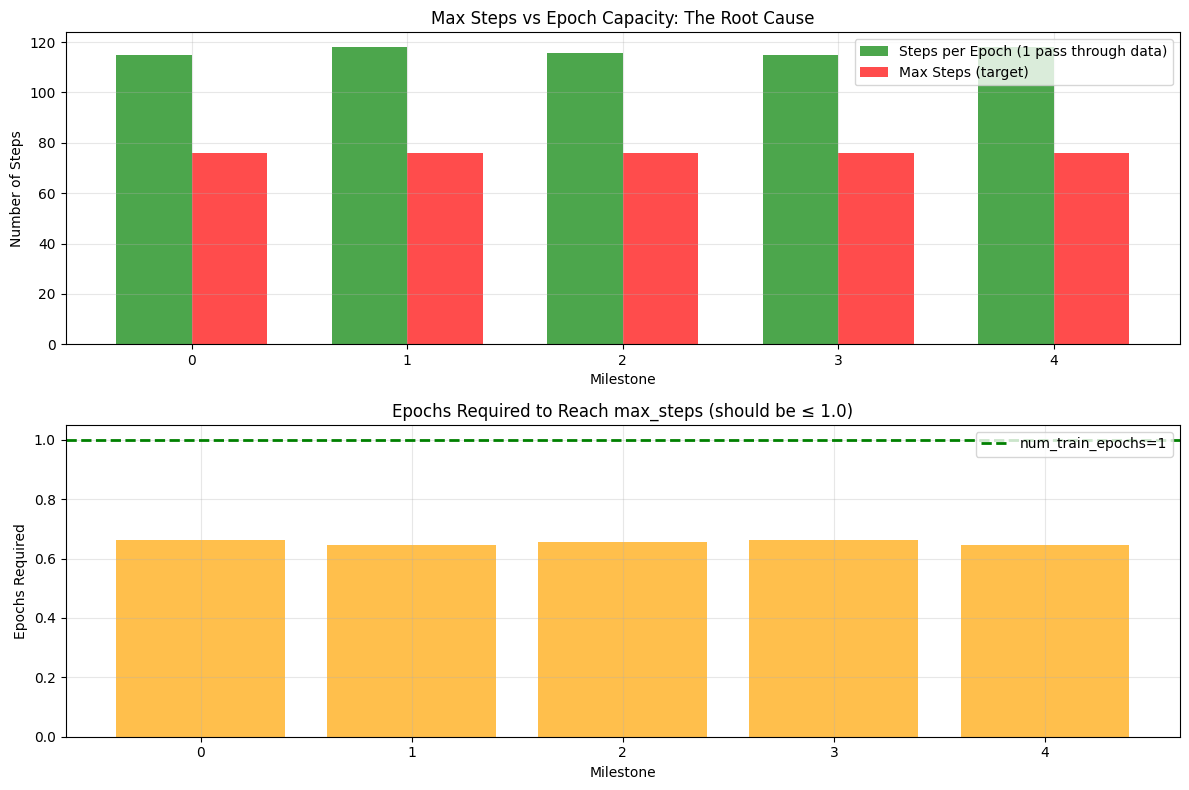


DIAGNOSIS COMPLETE


In [5]:
# Create visualization comparing max_steps vs steps_per_epoch
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

milestones = list(range(len(examples_per_milestone)))
max_steps_list = []
steps_per_epoch_list = []
epochs_required_list = []

for i, num_examples in enumerate(examples_per_milestone):
    train_examples = int(num_examples * (1 - validation_split))
    steps_per_epoch = train_examples / effective_batch_size
    max_steps = calculate_max_steps(
        target_tokens=target_tokens_per_milestone,
        batch_size=batch_size,
        grad_accum=grad_accum,
        seq_length=seq_length,
        world_size=world_size
    )
    epochs_required = max_steps / steps_per_epoch if steps_per_epoch > 0 else 0
    
    max_steps_list.append(max_steps)
    steps_per_epoch_list.append(steps_per_epoch)
    epochs_required_list.append(epochs_required)

# Plot 1: Max steps vs steps per epoch
x = np.arange(len(milestones))
width = 0.35

bars1 = ax1.bar(x - width/2, steps_per_epoch_list, width, label='Steps per Epoch (1 pass through data)', 
                color='green', alpha=0.7)
bars2 = ax1.bar(x + width/2, max_steps_list, width, label='Max Steps (target)', 
                color='red', alpha=0.7)

ax1.set_xlabel('Milestone')
ax1.set_ylabel('Number of Steps')
ax1.set_title('Max Steps vs Epoch Capacity: The Root Cause')
ax1.set_xticks(x)
ax1.set_xticklabels(milestones)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add horizontal line at y=steps_per_epoch to show the problem
for i in range(len(milestones)):
    if max_steps_list[i] > steps_per_epoch_list[i]:
        ax1.annotate('Dataset\nrestart!', 
                    xy=(i, max_steps_list[i]), 
                    xytext=(i, max_steps_list[i] + 10),
                    ha='center', fontsize=8, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Plot 2: Epochs required
bars3 = ax2.bar(milestones, epochs_required_list, color='orange', alpha=0.7)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='num_train_epochs=1')
ax2.set_xlabel('Milestone')
ax2.set_ylabel('Epochs Required')
ax2.set_title('Epochs Required to Reach max_steps (should be ≤ 1.0)')
ax2.set_xticks(milestones)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Highlight problematic milestones
for i, epochs in enumerate(epochs_required_list):
    if epochs > 1.0:
        ax2.text(i, epochs + 0.05, f'{epochs:.2f}x', ha='center', fontsize=9, 
                color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('epoch_restart_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("DIAGNOSIS COMPLETE")
print("="*80)

Indeed as expected we do have more than enough data per shard for each milestone, since we do provide a pretty generous buffer.

---

## 5. Test Packing Strategies (BFD vs Wrapped)

Now let's test whether the packing strategy affects the "rogue" short batches issue described in `Notes/sawtooth_issue_hypothesis.md`.

In [6]:
# Load dataset and tokenizer
from trl import pack_dataset
from datasets import load_from_disk
from transformers import AutoTokenizer

dataset_path = Path('../data/mixed_milestone_dataset')
dataset = load_from_disk(dataset_path)

model_name = metadata['config_snapshot']['model_name']
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Dataset loaded: {len(dataset)} examples")
print(f"Columns: {dataset.column_names}")
print(f"Tokenizer loaded: {model_name}")
print(f"Vocab size: {len(tokenizer)}")

/home/dan-parii/.pyenv/versions/finetuning-ro-llms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded: 219505 examples
Columns: ['formatted_text', 'ds_source', 'num_tokens', 'milestone_num']
Tokenizer loaded: meta-llama/Llama-3.2-1B-Instruct
Vocab size: 128256


In [7]:
# Store the original _pack_bfd function to restore between runs
_original_pack_bfd = None

def tokenize_dataset(milestone_data, text_field="formatted_text"):
    """
    Tokenize the dataset before packing.
    
    Args:
        milestone_data: Dataset with text to tokenize
        text_field: Column name containing text
        
    Returns:
        Dataset with ONLY input_ids and attention_mask (required for pack_dataset)
    """
    def tokenize_function(examples):
        return tokenizer(
            examples[text_field],
            truncation=False,  # Don't truncate yet, packing will handle it
            padding=False,      # Don't pad yet, packing will handle it
        )
    
    # Tokenize the dataset and remove ALL original columns
    # pack_dataset expects ONLY input_ids and attention_mask
    tokenized = milestone_data.map(
        tokenize_function,
        batched=True,
        remove_columns=milestone_data.column_names,  # Remove ALL columns, keep only tokens
        num_proc=4,
    )
    
    return tokenized


def analyze_packing(milestone_data, strategy, seq_length=2048, custom_packing_method=None):
    """
    Tokenize, pack, and analyze token distribution.
    
    Args:
        milestone_data: Dataset for a single milestone (with formatted_text)
        strategy: "bfd" or "wrapped"
        seq_length: Maximum sequence length
        custom_packing_method: Optional function to patch packing behavior
        
    Returns:
        dict with statistics about packing efficiency
    """
    global _original_pack_bfd
    
    print(f"  Tokenizing...")
    tokenized_data = tokenize_dataset(milestone_data)
    print(f"    Tokenized {len(tokenized_data)} examples")
    print(f"    Columns: {tokenized_data.column_names}")
    
    print(f"  Packing with strategy '{strategy}'...")
    
    # Save original _pack_bfd on first call
    if _original_pack_bfd is None:
        import trl.data_utils as data_utils
        _original_pack_bfd = data_utils._pack_bfd
    
    # Apply custom packing method if provided, otherwise restore original
    if custom_packing_method is not None:
        custom_packing_method()
    else:
        # Restore original packing function
        import trl.data_utils as data_utils
        data_utils._pack_bfd = _original_pack_bfd

    # Pack the dataset using TRL's pack_dataset
    packed_dataset = pack_dataset(
        dataset=tokenized_data,
        seq_length=seq_length,
        strategy=strategy,
    )
    
    print(f"    Packed into {len(packed_dataset)} sequences")
    
    # Analyze token counts in each packed sequence
    token_counts = []
    pad_id = tokenizer.pad_token_id
    
    for i in range(len(packed_dataset)):
        sample = packed_dataset[i]
        input_ids = np.array(sample['input_ids'])
        
        # Count non-padding tokens
        if pad_id is not None:
            real_tokens = (input_ids != pad_id).sum()
        else:
            real_tokens = len(input_ids)
        
        token_counts.append(real_tokens)
    
    token_counts = np.array(token_counts)
    
    # Calculate statistics (per sequence, not per batch)
    # Note: During training, batch_size sequences are processed together
    expected_tokens_per_seq = seq_length
    rogue_threshold = expected_tokens_per_seq * 0.5  # < 50% of expected per sequence
    rogue_seqs = token_counts < rogue_threshold
    
    stats = {
        'strategy': strategy,
        'num_packed': len(token_counts),
        'mean_tokens': token_counts.mean(),
        'std_tokens': token_counts.std(),
        'min_tokens': token_counts.min(),
        'max_tokens': token_counts.max(),
        'median_tokens': np.median(token_counts),
        'rogue_count': rogue_seqs.sum(),
        'rogue_ratio': rogue_seqs.mean(),
        'token_counts': token_counts,
    }
    
    print(f"    Mean tokens/seq: {stats['mean_tokens']:.0f}")
    print(f"    Std tokens/seq: {stats['std_tokens']:.0f}")
    print(f"    Min tokens/seq: {stats['min_tokens']:.0f}")
    print(f"    Rogue seqs (<50% of seq_length): {stats['rogue_count']} ({stats['rogue_ratio']:.1%})")
    
    return stats

In [8]:

def patch_trl_packing_for_stability(min_fill_ratio: float = 0.7):
    """
    Patch TRL's _pack_bfd function to filter out low-density packed sequences.
    This addresses the sawtooth loss issue caused by randomly-sampled low-density
    packed sequences during training. BFD (Best-Fit Decreasing) packing optimizes
    for global padding efficiency but doesn't enforce minimum bin fill ratios,
    leading to pathological training samples with <10-20% real tokens.
    See: continual_pretrain/Notes/SawToothLossFix_OverridePacking.md

    Args:
        min_fill_ratio: Minimum fraction of seq_length that bins must contain (default 0.7)
    """
    try:
        import pyarrow as pa
        import pyarrow.compute as pc
        import numpy as np
        from collections import defaultdict, deque
        import trl.data_utils as data_utils
        from trl.data_utils import _SegmentTree
    except (ImportError, AttributeError) as e:
        print(f"Could not import TRL dependencies for patching: {e}. Skipping patch.")
        return
    
    def filtered_pack_bfd(examples: pa.Table, seq_length: int) -> pa.Table:
        """Pack sequences using BFD with low-density bin filtering."""

        # =====================================================================
        # PART 1: Original TRL fragmentation and binning logic
        # =====================================================================

        # Identify the list column and prepare all columns
        columns = []
        list_column_idx = None
        for idx, column in enumerate(examples.columns):
            if isinstance(column, pa.ChunkedArray):
                column = column.combine_chunks()
            if not (pa.types.is_list(column.type) or pa.types.is_large_list(column.type)):
                raise TypeError("pack_dataset(bfd) requires all columns to be list-like.")
            if list_column_idx is None:
                list_column_idx = idx
            columns.append(column)

        assert list_column_idx is not None
        list_column = columns[list_column_idx]
        offsets = np.asarray(list_column.offsets)
        values = list_column.values

        # Split every list row into fragments of length <= seq_length
        frag_lengths: list[int] = []
        frag_info: list[tuple[int, int, int]] = []  # (row_idx, split_start, frag_len)
        expanded_indices: list[int] = []

        for row_idx, (row_start, row_end) in enumerate(zip(offsets[:-1], offsets[1:], strict=False)):
            length = row_end - row_start
            for split_start in range(0, length, seq_length):
                frag_len = min(seq_length, length - split_start)
                frag_lengths.append(frag_len)
                frag_info.append((row_idx, split_start, frag_len))
                expanded_indices.append(row_idx)

        # Rebuild list columns with fragments
        offsets_type = list_column.offsets.type
        new_offsets = np.empty(len(frag_lengths) + 1, dtype=offsets_type.to_pandas_dtype())
        new_offsets[0] = 0
        new_offsets[1:] = np.cumsum(frag_lengths, dtype=offsets_type.to_pandas_dtype())
        new_offsets_array = pa.array(new_offsets, type=offsets_type)

        for idx, column in enumerate(columns):
            if idx == list_column_idx:
                slices = [
                    values.slice(offsets[row_idx] + split_start, frag_len)
                    for row_idx, split_start, frag_len in frag_info
                ]
                new_values = pa.concat_arrays(slices)
                columns[idx] = type(column).from_arrays(new_offsets_array, new_values)
                continue

            column_offsets = np.asarray(column.offsets)
            column_values = column.values
            slices = []
            for row_idx, split_start, frag_len in frag_info:
                row_len = column_offsets[row_idx + 1] - column_offsets[row_idx]
                if row_len < split_start + frag_len:
                    raise ValueError("List columns must have matching lengths when packing datasets.")
                start = column_offsets[row_idx] + split_start
                slices.append(column_values.slice(start, frag_len))
            column_offsets_array = pa.array(new_offsets, type=column.offsets.type)
            columns[idx] = type(column).from_arrays(column_offsets_array, pa.concat_arrays(slices))

        examples = pa.Table.from_arrays(columns, names=examples.column_names)
        ids = np.arange(len(examples))
        lengths = pc.list_value_length(examples[list_column_idx]).combine_chunks()
        examples = examples.append_column("seq_lengths", lengths)
        lengths = pc.make_struct(lengths, ids)
        lengths = lengths.sort("descending", by=0)

        # Greedy BFD binning
        segment_tree = _SegmentTree(seq_length)
        segment_tree.add(seq_length)
        space_to_bin = defaultdict(deque)
        bins: list[dict] = []

        for length, idx in zip(lengths.field(0).to_numpy(), lengths.field(1).to_numpy(), strict=True):
            space = segment_tree.search(length)
            if space < seq_length:
                bin = space_to_bin[space].popleft()
            else:
                bin = {"ids": [], "length": 0}
                bins.append(bin)
            bin["ids"].append(idx)
            bin["length"] += length
            if space < seq_length and not space_to_bin[space]:
                segment_tree.remove(space)
            space = space - length
            space_to_bin[space].append(bin)
            if space > 0:
                segment_tree.add(space)

        # =====================================================================
        # PART 2: Filter low-density bins (NEW FIX)
        # =====================================================================

        total_bins_before = len(bins)
        min_tokens = int(min_fill_ratio * seq_length)

        bins_filtered = [bin for bin in bins if bin["length"] >= min_tokens]
        bins_dropped = total_bins_before - len(bins_filtered)

        if bins_dropped > 0:
            dropped_ratio = bins_dropped / total_bins_before
            print(
                f"Dropped {bins_dropped}/{total_bins_before} low-density packed bins "
                f"({dropped_ratio:.1%}) with fill ratio < {min_fill_ratio:.0%} "
                f"(min_tokens={min_tokens}, seq_length={seq_length})"
            )
            # Log details about dropped bins for debugging
            dropped_bins = [bin for bin in bins if bin["length"] < min_tokens]
            if dropped_bins:
                dropped_lengths = [bin["length"] for bin in dropped_bins]
                print(
                    f"   Dropped bin lengths: min={min(dropped_lengths)}, "
                    f"max={max(dropped_lengths)}, mean={np.mean(dropped_lengths):.0f}"
                )
        else:
            print(
                f"✓ All {total_bins_before} packed bins passed min_fill_ratio={min_fill_ratio:.0%} filter"
            )

        bins = bins_filtered

        # =====================================================================
        # PART 3: Reconstruct PyArrow table from filtered bins (original logic)
        # =====================================================================

        examples = pc.take(examples, [id_ for bin in bins for id_ in bin["ids"]])
        offsets = np.cumsum([0] + [bin["length"] for bin in bins])

        assert all(column.num_chunks == 1 for column in examples.columns)
        lengths = examples["seq_lengths"].chunks[0]
        examples = examples.drop_columns("seq_lengths")
        lengths = pa.ListArray.from_arrays(
            np.cumsum([0] + [len(bin["ids"]) for bin in bins], dtype=np.int32),
            lengths
        )

        columns = []
        for column in examples.columns:
            column = column.chunks[0]
            if pa.types.is_list(column.type) or pa.types.is_large_list(column.type):
                dtype = column.offsets.type.to_pandas_dtype()
                column = type(column).from_arrays(offsets.astype(dtype), column.values)
            columns.append(column)

        return pa.Table.from_arrays(columns + [lengths], names=examples.column_names + ["seq_lengths"])
    


    data_utils._pack_bfd = filtered_pack_bfd


In [9]:
# Run packing analysis for all milestones with both strategies
results = {}

for milestone_num in range(metadata['num_milestones']):
    print(f"\nMilestone {milestone_num}:")
    
    # Filter dataset to this milestone
    milestone_data = dataset.filter(lambda x: x['milestone_num'] == milestone_num)
    
    # Test both strategies
    bfd_stats = analyze_packing(milestone_data, 'bfd', seq_length)
    wrapped_stats = analyze_packing(milestone_data, 'bfd', seq_length, patch_trl_packing_for_stability, )
    
    results[milestone_num] = {
        'bfd': bfd_stats,
        'custom_bfd': wrapped_stats,
    }

print("\n" + "="*80)
print("PACKING ANALYSIS COMPLETE")
print("="*80)


Milestone 0:
  Tokenizing...
    Tokenized 4084 examples
    Columns: ['input_ids', 'attention_mask']
  Packing with strategy 'bfd'...
    Packed into 2105 sequences
    Mean tokens/seq: 2040
    Std tokens/seq: 58
    Min tokens/seq: 649
    Rogue seqs (<50% of seq_length): 4 (0.2%)
  Tokenizing...
    Tokenized 4084 examples
    Columns: ['input_ids', 'attention_mask']
  Packing with strategy 'bfd'...
    Packed into 2446 sequences
    Mean tokens/seq: 2044
    Std tokens/seq: 16
    Min tokens/seq: 1542
    Rogue seqs (<50% of seq_length): 0 (0.0%)

Milestone 1:
  Tokenizing...
    Tokenized 4195 examples
    Columns: ['input_ids', 'attention_mask']
  Packing with strategy 'bfd'...
    Packed into 2153 sequences
    Mean tokens/seq: 2039
    Std tokens/seq: 69
    Min tokens/seq: 107
    Rogue seqs (<50% of seq_length): 3 (0.1%)
  Tokenizing...
    Tokenized 4195 examples
    Columns: ['input_ids', 'attention_mask']
  Packing with strategy 'bfd'...
    Packed into 2447 sequences
  

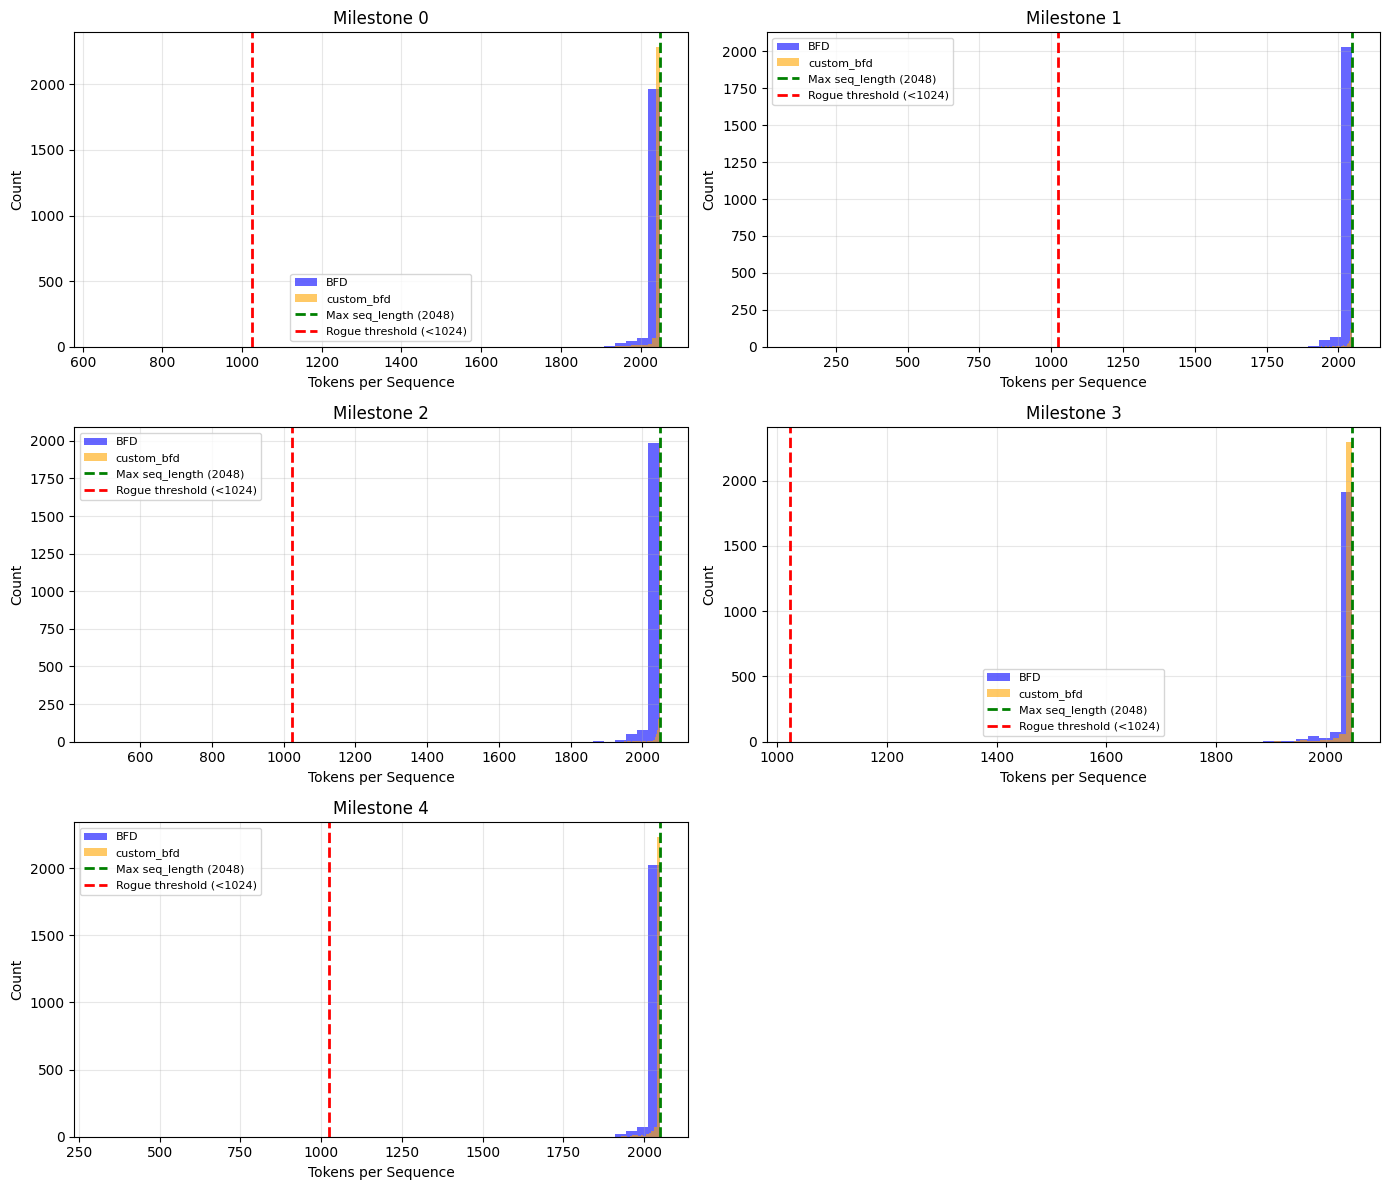

In [12]:
# Visualize comparison across all milestones
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for milestone_num in range(metadata['num_milestones']):
    ax = axes[milestone_num]
    
    bfd_counts = results[milestone_num]['bfd']['token_counts']
    wrapped_counts = results[milestone_num]['custom_bfd']['token_counts']
    
    # Plot histograms
    ax.hist(bfd_counts, bins=50, alpha=0.6, label='BFD', color='blue')
    ax.hist(wrapped_counts, bins=50, alpha=0.6, label='custom_bfd', color='orange')
    
    # Mark the expected tokens per sequence and rogue threshold
    expected_per_seq = seq_length
    rogue_thresh = expected_per_seq * 0.5
    
    ax.axvline(expected_per_seq, color='green', linestyle='--', linewidth=2, label=f'Max seq_length ({expected_per_seq})')
    ax.axvline(rogue_thresh, color='red', linestyle='--', linewidth=2, label=f'Rogue threshold (<{rogue_thresh:.0f})')
    
    ax.set_xlabel('Tokens per Sequence')
    ax.set_ylabel('Count')
    ax.set_title(f'Milestone {milestone_num}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove extra subplot if odd number of milestones
if metadata['num_milestones'] < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('packing_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

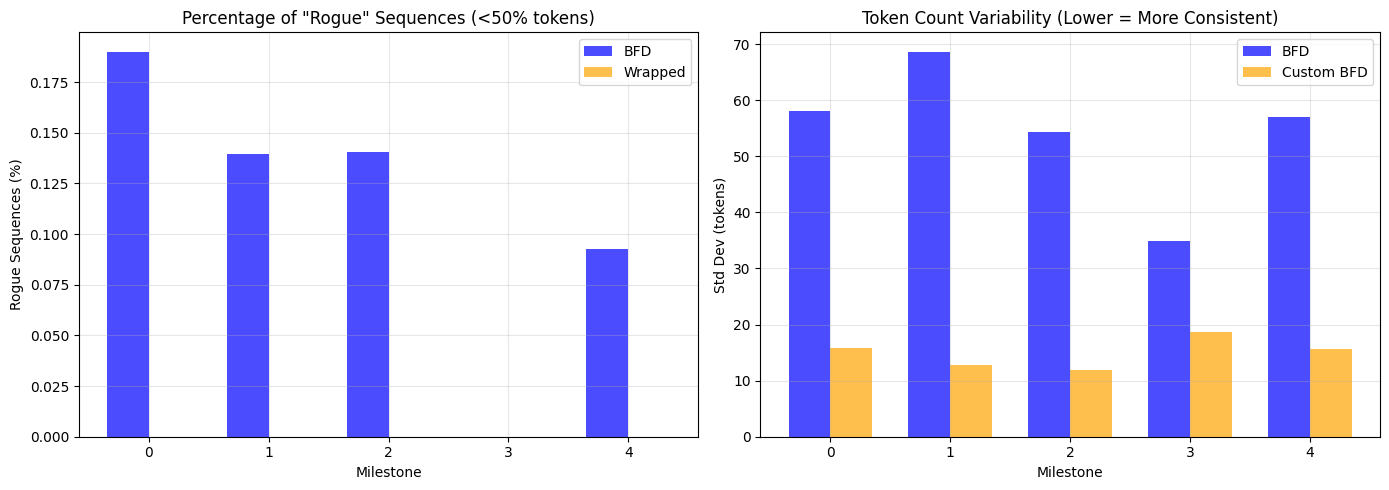


KEY FINDINGS:

BFD Strategy:
  Avg rogue ratio: 0.1%
  Avg std dev: 55 tokens

Wrapped Strategy:
  Avg rogue ratio: 0.0%
  Avg std dev: 15 tokens

Conclusion: Wrapped has fewer rogue batches


In [14]:
# Summary comparison: Rogue batch ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

milestones = list(range(metadata['num_milestones']))
bfd_rogue_ratios = [results[m]['bfd']['rogue_ratio'] * 100 for m in milestones]
wrapped_rogue_ratios = [results[m]['custom_bfd']['rogue_ratio'] * 100 for m in milestones]

x = np.arange(len(milestones))
width = 0.35

# Plot 1: Rogue batch percentages
ax1.bar(x - width/2, bfd_rogue_ratios, width, label='BFD', color='blue', alpha=0.7)
ax1.bar(x + width/2, wrapped_rogue_ratios, width, label='Wrapped', color='orange', alpha=0.7)
ax1.set_xlabel('Milestone')
ax1.set_ylabel('Rogue Sequences (%)')
ax1.set_title('Percentage of "Rogue" Sequences (<50% tokens)')
ax1.set_xticks(x)
ax1.set_xticklabels(milestones)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Standard deviation comparison
bfd_stds = [results[m]['bfd']['std_tokens'] for m in milestones]
wrapped_stds = [results[m]['custom_bfd']['std_tokens'] for m in milestones]

ax2.bar(x - width/2, bfd_stds, width, label='BFD', color='blue', alpha=0.7)
ax2.bar(x + width/2, wrapped_stds, width, label='Custom BFD', color='orange', alpha=0.7)
ax2.set_xlabel('Milestone')
ax2.set_ylabel('Std Dev (tokens)')
ax2.set_title('Token Count Variability (Lower = More Consistent)')
ax2.set_xticks(x)
ax2.set_xticklabels(milestones)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('packing_strategy_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"\nBFD Strategy:")
print(f"  Avg rogue ratio: {np.mean(bfd_rogue_ratios):.1f}%")
print(f"  Avg std dev: {np.mean(bfd_stds):.0f} tokens")
print(f"\nWrapped Strategy:")
print(f"  Avg rogue ratio: {np.mean(wrapped_rogue_ratios):.1f}%")
print(f"  Avg std dev: {np.mean(wrapped_stds):.0f} tokens")
print(f"\nConclusion: {'BFD' if np.mean(bfd_rogue_ratios) < np.mean(wrapped_rogue_ratios) else 'Wrapped'} has fewer rogue batches")